# 07_error_analysis.ipynb

Notebook này dùng để phân tích lỗi của mô hình tốt nhất sau giai đoạn tuning CS114.

Mục tiêu chính:

1. Đọc file prediction của **best tuned model**.
2. Kiểm tra tổng số ảnh đúng/sai trên test set.
3. Tính precision, recall, F1-score và accuracy theo từng lớp.
4. Vẽ confusion matrix dạng số lượng và dạng chuẩn hóa theo phần trăm.
5. Tìm các cặp lớp bị nhầm nhiều nhất.
6. Hiển thị các ảnh dự đoán sai tiêu biểu.
7. Lưu toàn bộ bảng kết quả và hình ảnh để dùng trong báo cáo.

Notebook này được thiết kế để chạy được trên **Google Colab trước**, sau đó có thể chuyển về **local** chạy lại bằng cách chỉnh biến `PROJECT_ROOT`.


## 1. Mount Google Drive nếu chạy trên Colab

Nếu project của bạn nằm trong Google Drive thì cần mount Drive trước.

Nếu chạy local, cell này sẽ tự bỏ qua.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Không chạy trong Google Colab, bỏ qua bước mount Google Drive.")


Mounted at /content/drive


## 2. Cấu hình đường dẫn project

Bạn chỉ cần sửa biến `PROJECT_ROOT` cho đúng vị trí thư mục project.

Ví dụ trên Colab:

```python
PROJECT_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")
```

Ví dụ khi chạy local:

```python
PROJECT_ROOT = Path(r"D:/Study/CS231/intel_image_project")
```

Notebook sẽ tự tạo các thư mục output nếu chưa tồn tại.


In [ ]:
from pathlib import Path
import os

# ============================================================
# CHỈ CẦN SỬA DÒNG NÀY KHI ĐỔI MÔI TRƯỜNG CHẠY
# ============================================================
PROJECT_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")

# Dữ liệu gốc
RAW_DIR = PROJECT_ROOT / "data" / "raw"

# File split và metadata sinh ra từ các notebook trước
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"

# Output chung
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "cs114"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"

# Output riêng cho error analysis
ERROR_FIGURES_DIR = FIGURES_DIR / "error_analysis"
ERROR_EXAMPLES_DIR = ERROR_FIGURES_DIR / "misclassified_examples"
ERROR_TABLES_DIR = METRICS_DIR

# Tạo thư mục nếu chưa có
for d in [FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, ERROR_FIGURES_DIR, ERROR_EXAMPLES_DIR, ERROR_TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("METADATA_DIR:", METADATA_DIR)
print("PREDICTIONS_DIR:", PREDICTIONS_DIR)
print("ERROR_FIGURES_DIR:", ERROR_FIGURES_DIR)
print("ERROR_EXAMPLES_DIR:", ERROR_EXAMPLES_DIR)


PROJECT_ROOT: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project
RAW_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw
SPLITS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/splits
METADATA_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/metadata
PREDICTIONS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions
ERROR_FIGURES_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis
ERROR_EXAMPLES_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/misclassified_examples


## 3. Import thư viện và thiết lập chung

Các thư viện chính:

- `pandas`, `numpy`: xử lý bảng dữ liệu.
- `matplotlib`: vẽ biểu đồ và hiển thị ảnh.
- `sklearn.metrics`: tính classification report và confusion matrix.
- `PIL`: đọc ảnh gốc để hiển thị ví dụ dự đoán sai.


In [ ]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Markdown

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Nếu bạn dùng bản full data thì mode là "full".
# Biến này được dùng để đặt tên file output.
MODE = "full"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("SEED:", SEED)
print("MODE:", MODE)


SEED: 42
MODE: full


## 4. Đọc file prediction của best tuned model

File prediction được tạo từ notebook `04_cs114_tuning.ipynb`.

File chính cần đọc:

```text
outputs/predictions/cs114_best_tuned_model_test_predictions_full.csv
```

File này thường có các cột quan trọng:

```text
relative_path
true_label
pred_label
true_label_idx
pred_label_idx
is_correct
```

Nếu notebook tuning của bạn có thêm các cột khác thì vẫn giữ nguyên, không ảnh hưởng đến phân tích lỗi.


In [ ]:
PREDICTION_PATH = PREDICTIONS_DIR / f"cs114_best_tuned_model_test_predictions_{MODE}.csv"

if not PREDICTION_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file prediction: {PREDICTION_PATH}\n"
        "Hãy kiểm tra lại PROJECT_ROOT hoặc đảm bảo bạn đã chạy xong notebook 04_cs114_tuning.ipynb."
    )

pred_df = pd.read_csv(PREDICTION_PATH)

print("Đã đọc file prediction:")
print(PREDICTION_PATH)
print("Shape:", pred_df.shape)

display(pred_df.head())
print("Các cột hiện có:")
print(list(pred_df.columns))


Đã đọc file prediction:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions/cs114_best_tuned_model_test_predictions_full.csv
Shape: (3000, 15)


,relative_path,true_label,pred_label,true_label_idx,pred_label_idx,is_correct,split,label,file_name,width,height,mode,error,file_hash,label_idx
0,seg_test/buildings/20057.jpg,buildings,buildings,0,0,True,test,buildings,20057.jpg,150,150,RGB,NaN,c05af5c7bcce817b4e03c89cf99523b3,0
1,seg_test/buildings/20060.jpg,buildings,street,0,5,False,test,buildings,20060.jpg,150,150,RGB,NaN,294b7b292e7ba7d938b7819cde55125c,0
2,seg_test/buildings/20061.jpg,buildings,buildings,0,0,True,test,buildings,20061.jpg,150,150,RGB,NaN,1dc62bcc7c181f63d546cef3a108ac0e,0
3,seg_test/buildings/20064.jpg,buildings,buildings,0,0,True,test,buildings,20064.jpg,150,150,RGB,NaN,b1369f91a642bda82a51b041f97870a9,0
4,seg_test/buildings/20073.jpg,buildings,glacier,0,2,False,test,buildings,20073.jpg,150,150,RGB,NaN,3c520c75fde0970f78531d6fbaa334bb,0


Các cột hiện có:
['relative_path', 'true_label', 'pred_label', 'true_label_idx', 'pred_label_idx', 'is_correct', 'split', 'label', 'file_name', 'width', 'height', 'mode', 'error', 'file_hash', 'label_idx']


## 5. Đọc tên lớp và chuẩn hóa các cột cần thiết

Notebook sẽ ưu tiên đọc `class_to_idx.json` từ thư mục metadata.

Nếu không tìm thấy file này, notebook sẽ tự suy ra danh sách lớp từ cột `true_label` và `pred_label` trong file prediction.

Mục tiêu của bước này là đảm bảo luôn có đầy đủ:

```text
class_names
class_to_idx
idx_to_class
true_label_idx
pred_label_idx
true_label
pred_label
is_correct
```


In [ ]:
def load_class_mapping(prediction_df):
    class_to_idx_path = METADATA_DIR / "class_to_idx.json"

    if class_to_idx_path.exists():
        with open(class_to_idx_path, "r", encoding="utf-8") as f:
            class_to_idx = json.load(f)

        # Đảm bảo value là int
        class_to_idx = {str(k): int(v) for k, v in class_to_idx.items()}
        idx_to_class = {int(v): str(k) for k, v in class_to_idx.items()}
        class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

        print("Đã đọc class mapping từ:", class_to_idx_path)
    else:
        print("Không tìm thấy class_to_idx.json. Suy ra class names từ prediction CSV.")

        labels = []
        if "true_label" in prediction_df.columns:
            labels.extend(prediction_df["true_label"].dropna().astype(str).unique().tolist())
        if "pred_label" in prediction_df.columns:
            labels.extend(prediction_df["pred_label"].dropna().astype(str).unique().tolist())

        class_names = sorted(set(labels))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        idx_to_class = {i: name for name, i in class_to_idx.items()}

    return class_names, class_to_idx, idx_to_class


class_names, class_to_idx, idx_to_class = load_class_mapping(pred_df)

print("Số lớp:", len(class_names))
print("class_names:", class_names)
print("class_to_idx:", class_to_idx)


Đã đọc class mapping từ: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/metadata/class_to_idx.json
Số lớp: 6
class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
class_to_idx: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [ ]:
def normalize_prediction_columns(df):
    df = df.copy()

    # Nếu thiếu true_label_idx nhưng có true_label thì map từ class_to_idx
    if "true_label_idx" not in df.columns:
        if "true_label" not in df.columns:
            raise ValueError("Prediction CSV thiếu cả true_label_idx và true_label.")
        df["true_label_idx"] = df["true_label"].astype(str).map(class_to_idx)

    # Nếu thiếu pred_label_idx nhưng có pred_label thì map từ class_to_idx
    if "pred_label_idx" not in df.columns:
        if "pred_label" not in df.columns:
            raise ValueError("Prediction CSV thiếu cả pred_label_idx và pred_label.")
        df["pred_label_idx"] = df["pred_label"].astype(str).map(class_to_idx)

    # Nếu thiếu true_label thì map ngược từ idx_to_class
    if "true_label" not in df.columns:
        df["true_label"] = df["true_label_idx"].astype(int).map(idx_to_class)

    # Nếu thiếu pred_label thì map ngược từ idx_to_class
    if "pred_label" not in df.columns:
        df["pred_label"] = df["pred_label_idx"].astype(int).map(idx_to_class)

    # Ép kiểu index về int
    df["true_label_idx"] = df["true_label_idx"].astype(int)
    df["pred_label_idx"] = df["pred_label_idx"].astype(int)

    # Nếu thiếu is_correct thì tự tính
    if "is_correct" not in df.columns:
        df["is_correct"] = df["true_label_idx"] == df["pred_label_idx"]

    df["is_correct"] = df["is_correct"].astype(bool)

    # Kiểm tra cột đường dẫn ảnh
    if "relative_path" not in df.columns:
        possible_path_cols = ["image_path", "path", "filepath", "file_path"]
        found = None
        for col in possible_path_cols:
            if col in df.columns:
                found = col
                break

        if found is not None:
            df["relative_path"] = df[found]
        else:
            print("Cảnh báo: không tìm thấy cột relative_path. Phần hiển thị ảnh có thể không chạy được.")

    return df


pred_df = normalize_prediction_columns(pred_df)

required_cols = ["true_label", "pred_label", "true_label_idx", "pred_label_idx", "is_correct"]
missing_cols = [c for c in required_cols if c not in pred_df.columns]

if missing_cols:
    raise ValueError(f"Thiếu các cột bắt buộc: {missing_cols}")

print("Đã chuẩn hóa prediction dataframe.")
display(pred_df.head())


Đã chuẩn hóa prediction dataframe.


,relative_path,true_label,pred_label,true_label_idx,pred_label_idx,is_correct,split,label,file_name,width,height,mode,error,file_hash,label_idx
0,seg_test/buildings/20057.jpg,buildings,buildings,0,0,True,test,buildings,20057.jpg,150,150,RGB,NaN,c05af5c7bcce817b4e03c89cf99523b3,0
1,seg_test/buildings/20060.jpg,buildings,street,0,5,False,test,buildings,20060.jpg,150,150,RGB,NaN,294b7b292e7ba7d938b7819cde55125c,0
2,seg_test/buildings/20061.jpg,buildings,buildings,0,0,True,test,buildings,20061.jpg,150,150,RGB,NaN,1dc62bcc7c181f63d546cef3a108ac0e,0
3,seg_test/buildings/20064.jpg,buildings,buildings,0,0,True,test,buildings,20064.jpg,150,150,RGB,NaN,b1369f91a642bda82a51b041f97870a9,0
4,seg_test/buildings/20073.jpg,buildings,glacier,0,2,False,test,buildings,20073.jpg,150,150,RGB,NaN,3c520c75fde0970f78531d6fbaa334bb,0


## 6. Thống kê tổng quan kết quả đúng/sai

Bước này giúp trả lời các câu hỏi cơ bản:

- Tổng số ảnh test là bao nhiêu?
- Mô hình dự đoán đúng bao nhiêu ảnh?
- Mô hình dự đoán sai bao nhiêu ảnh?
- Accuracy kiểm tra lại từ prediction CSV là bao nhiêu?


In [ ]:
y_true = pred_df["true_label_idx"].values
y_pred = pred_df["pred_label_idx"].values

n_total = len(pred_df)
n_correct = int(pred_df["is_correct"].sum())
n_wrong = int(n_total - n_correct)
accuracy = accuracy_score(y_true, y_pred)

summary_overall = {
    "mode": MODE,
    "n_total": n_total,
    "n_correct": n_correct,
    "n_wrong": n_wrong,
    "accuracy": float(accuracy),
    "error_rate": float(1 - accuracy)
}

summary_overall_df = pd.DataFrame([summary_overall])

display(summary_overall_df)

print(f"Tổng số ảnh test : {n_total}")
print(f"Số ảnh đúng      : {n_correct}")
print(f"Số ảnh sai       : {n_wrong}")
print(f"Accuracy         : {accuracy:.4f}")
print(f"Error rate       : {1 - accuracy:.4f}")


,mode,n_total,n_correct,n_wrong,accuracy,error_rate
0,full,3000,1959,1041,0.653,0.347


Tổng số ảnh test : 3000
Số ảnh đúng      : 1959
Số ảnh sai       : 1041
Accuracy         : 0.6530
Error rate       : 0.3470


## 7. Classification report theo từng lớp

Classification report cho biết hiệu quả của model trên từng lớp thông qua:

- **Precision**: trong các ảnh model dự đoán là lớp đó, có bao nhiêu ảnh đúng.
- **Recall**: trong các ảnh thật sự thuộc lớp đó, model nhận ra đúng bao nhiêu ảnh.
- **F1-score**: trung bình điều hòa giữa precision và recall.
- **Support**: số lượng ảnh thật của lớp đó trong test set.

Trong bài toán nhiều lớp, `macro_f1` rất quan trọng vì nó đánh giá trung bình đều giữa các lớp, không thiên về lớp có nhiều mẫu hơn.


In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# Tách riêng phần per-class để dễ phân tích
per_class_report_df = report_df.loc[class_names].copy()
per_class_report_df = per_class_report_df.reset_index().rename(columns={"index": "class_name"})

# Làm tròn để hiển thị đẹp hơn
per_class_report_display = per_class_report_df.copy()
for col in ["precision", "recall", "f1-score"]:
    per_class_report_display[col] = per_class_report_display[col].round(4)
per_class_report_display["support"] = per_class_report_display["support"].astype(int)

display(per_class_report_display)

print("Classification report đầy đủ:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))


,class_name,precision,recall,f1-score,support
0,buildings,0.7440,0.7048,0.7239,437
1,forest,0.8265,0.8945,0.8592,474
2,glacier,0.5588,0.5497,0.5542,553
3,mountain,0.4775,0.5257,0.5005,525
4,sea,0.5928,0.5510,0.5711,510
5,street,0.7673,0.7305,0.7485,501


Classification report đầy đủ:
              precision    recall  f1-score   support

   buildings       0.74      0.70      0.72       437
      forest       0.83      0.89      0.86       474
     glacier       0.56      0.55      0.55       553
    mountain       0.48      0.53      0.50       525
         sea       0.59      0.55      0.57       510
      street       0.77      0.73      0.75       501

    accuracy                           0.65      3000
   macro avg       0.66      0.66      0.66      3000
weighted avg       0.65      0.65      0.65      3000



## 8. Per-class accuracy

`Recall` cho biết tỉ lệ nhận đúng trên từng lớp. Tuy nhiên, trong báo cáo ta có thể gọi trực quan hơn là **per-class accuracy**:

```text
per-class accuracy = số ảnh đúng của lớp đó / tổng số ảnh thật của lớp đó
```

Chỉ số này giúp xác định lớp nào model đang làm tốt và lớp nào còn yếu.


In [ ]:
per_class_rows = []

for class_idx, class_name in enumerate(class_names):
    class_df = pred_df[pred_df["true_label_idx"] == class_idx]
    total = len(class_df)
    correct = int(class_df["is_correct"].sum())
    wrong = int(total - correct)
    acc = correct / total if total > 0 else 0.0

    per_class_rows.append({
        "class_idx": class_idx,
        "class_name": class_name,
        "total": total,
        "correct": correct,
        "wrong": wrong,
        "per_class_accuracy": acc
    })

per_class_acc_df = pd.DataFrame(per_class_rows)

# Ghép thêm precision, recall, f1-score
per_class_analysis_df = per_class_acc_df.merge(
    per_class_report_df[["class_name", "precision", "recall", "f1-score", "support"]],
    on="class_name",
    how="left"
)

per_class_analysis_display = per_class_analysis_df.copy()
for col in ["per_class_accuracy", "precision", "recall", "f1-score"]:
    per_class_analysis_display[col] = per_class_analysis_display[col].round(4)

display(per_class_analysis_display.sort_values("f1-score"))


,class_idx,class_name,total,correct,wrong,per_class_accuracy,precision,recall,f1-score,support
3,3,mountain,525,276,249,0.5257,0.4775,0.5257,0.5005,525.0
2,2,glacier,553,304,249,0.5497,0.5588,0.5497,0.5542,553.0
4,4,sea,510,281,229,0.5510,0.5928,0.5510,0.5711,510.0
0,0,buildings,437,308,129,0.7048,0.7440,0.7048,0.7239,437.0
5,5,street,501,366,135,0.7305,0.7673,0.7305,0.7485,501.0
1,1,forest,474,424,50,0.8945,0.8265,0.8945,0.8592,474.0


## 9. Vẽ biểu đồ F1-score và per-class accuracy

Hai biểu đồ này dùng để nhìn nhanh lớp nào tốt, lớp nào yếu.

Trong báo cáo, bạn nên nhận xét theo hướng:

- Lớp có F1-score cao nhất là gì?
- Lớp có F1-score thấp nhất là gì?
- Các lớp yếu có đặc điểm thị giác nào dễ gây nhầm lẫn?


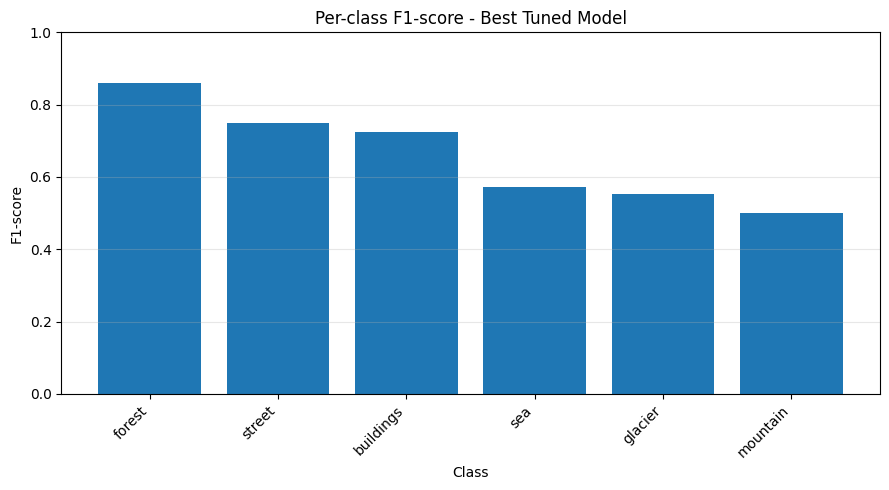

Đã lưu biểu đồ tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/per_class_f1_best_tuned_model_full.png


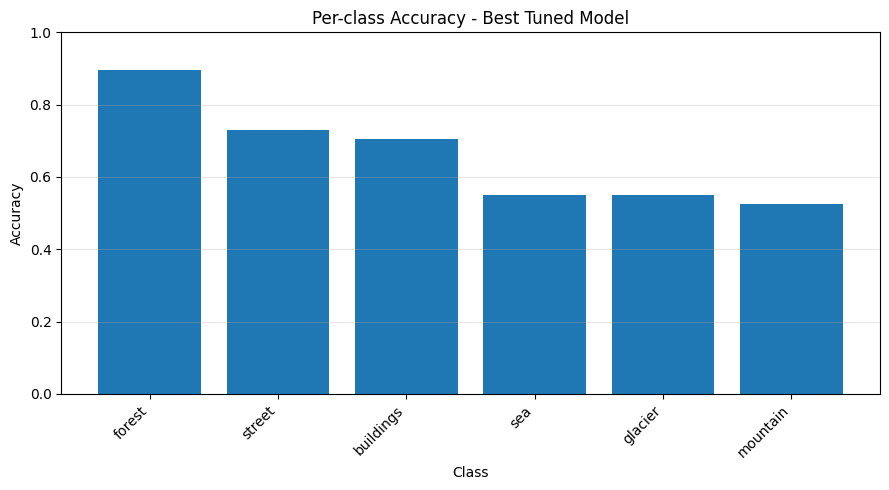

Đã lưu biểu đồ tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/per_class_accuracy_best_tuned_model_full.png


In [ ]:
def save_and_show_bar_chart(df, x_col, y_col, title, ylabel, output_path, sort_by=None):
    plot_df = df.copy()
    if sort_by is not None:
        plot_df = plot_df.sort_values(sort_by, ascending=False)

    plt.figure(figsize=(9, 5))
    plt.bar(plot_df[x_col], plot_df[y_col])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel(ylabel)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

    print("Đã lưu biểu đồ tại:")
    print(output_path)


f1_chart_path = ERROR_FIGURES_DIR / f"per_class_f1_best_tuned_model_{MODE}.png"
acc_chart_path = ERROR_FIGURES_DIR / f"per_class_accuracy_best_tuned_model_{MODE}.png"

save_and_show_bar_chart(
    df=per_class_analysis_df,
    x_col="class_name",
    y_col="f1-score",
    title="Per-class F1-score - Best Tuned Model",
    ylabel="F1-score",
    output_path=f1_chart_path,
    sort_by="f1-score"
)

save_and_show_bar_chart(
    df=per_class_analysis_df,
    x_col="class_name",
    y_col="per_class_accuracy",
    title="Per-class Accuracy - Best Tuned Model",
    ylabel="Accuracy",
    output_path=acc_chart_path,
    sort_by="per_class_accuracy"
)


## 10. Confusion matrix dạng số lượng

Confusion matrix cho biết model đang nhầm lớp nào sang lớp nào.

Cách đọc:

- Trục dọc: nhãn thật.
- Trục ngang: nhãn dự đoán.
- Đường chéo chính: số ảnh dự đoán đúng.
- Các ô ngoài đường chéo: số ảnh bị dự đoán sai.


,buildings,forest,glacier,mountain,sea,street
buildings,308,16,18,19,19,57
forest,8,424,15,3,2,22
glacier,7,16,304,135,72,19
mountain,15,6,128,276,93,7
sea,18,5,61,139,281,6
street,58,46,18,6,7,366


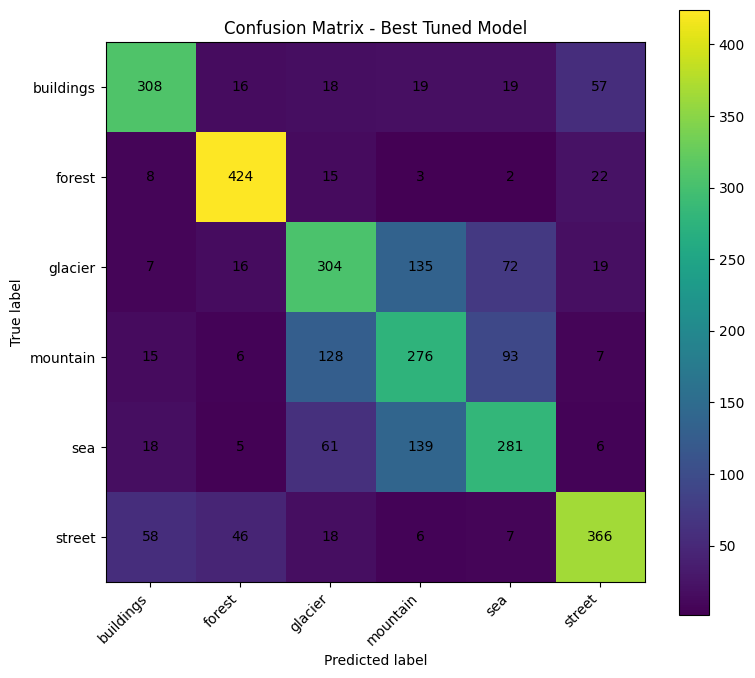

Đã lưu confusion matrix dạng số lượng tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/confusion_matrix_raw_best_tuned_model_full.png


In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(class_names)))
)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
display(cm_df)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Confusion Matrix - Best Tuned Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_raw_path = ERROR_FIGURES_DIR / f"confusion_matrix_raw_best_tuned_model_{MODE}.png"
plt.savefig(cm_raw_path, dpi=150)
plt.show()

print("Đã lưu confusion matrix dạng số lượng tại:")
print(cm_raw_path)


## 11. Confusion matrix dạng chuẩn hóa theo phần trăm

Confusion matrix dạng số lượng cho biết số ảnh bị nhầm.

Tuy nhiên, để so sánh công bằng giữa các lớp, ta nên dùng confusion matrix chuẩn hóa theo từng hàng:

```text
normalized value = số ảnh ở ô đó / tổng số ảnh thật của lớp tương ứng
```

Khi đó mỗi hàng có tổng xấp xỉ bằng 1.0, tương đương 100%.


,buildings,forest,glacier,mountain,sea,street
buildings,0.7048,0.0366,0.0412,0.0435,0.0435,0.1304
forest,0.0169,0.8945,0.0316,0.0063,0.0042,0.0464
glacier,0.0127,0.0289,0.5497,0.2441,0.1302,0.0344
mountain,0.0286,0.0114,0.2438,0.5257,0.1771,0.0133
sea,0.0353,0.0098,0.1196,0.2725,0.5510,0.0118
street,0.1158,0.0918,0.0359,0.0120,0.0140,0.7305


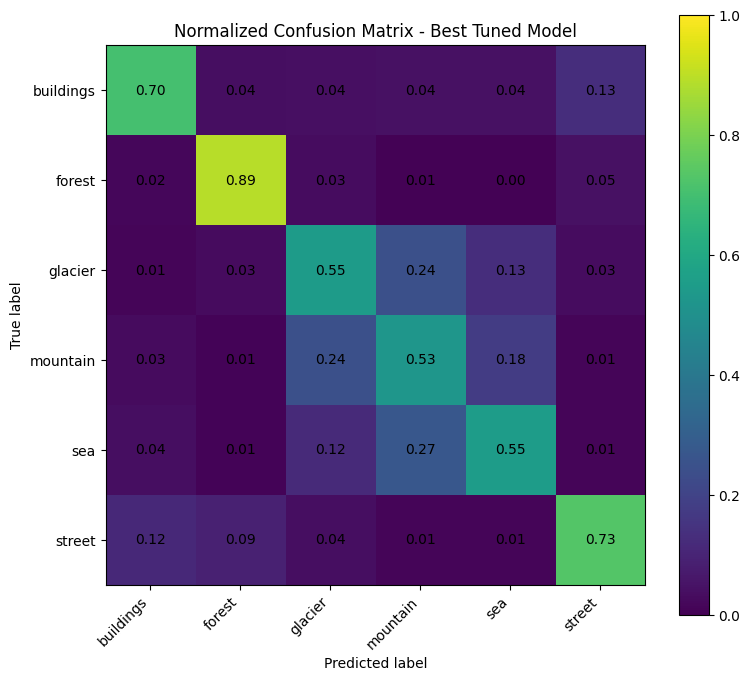

Đã lưu confusion matrix chuẩn hóa tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/confusion_matrix_normalized_best_tuned_model_full.png


In [ ]:
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)
display(cm_norm_df.round(4))

plt.figure(figsize=(8, 7))
plt.imshow(cm_norm, vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix - Best Tuned Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        value = cm_norm[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_norm_path = ERROR_FIGURES_DIR / f"confusion_matrix_normalized_best_tuned_model_{MODE}.png"
plt.savefig(cm_norm_path, dpi=150)
plt.show()

print("Đã lưu confusion matrix chuẩn hóa tại:")
print(cm_norm_path)


## 12. Tìm các cặp lớp bị nhầm nhiều nhất

Bước này lấy các ô ngoài đường chéo chính của confusion matrix.

Ví dụ:

```text
true_label = glacier, pred_label = mountain
```

nghĩa là ảnh thật thuộc lớp `glacier` nhưng model dự đoán nhầm thành `mountain`.

Đây là bảng rất quan trọng để viết phần phân tích lỗi trong báo cáo.


In [ ]:
confusion_rows = []

for true_idx, true_name in enumerate(class_names):
    total_true = cm[true_idx].sum()

    for pred_idx, pred_name in enumerate(class_names):
        if true_idx == pred_idx:
            continue

        count = int(cm[true_idx, pred_idx])
        rate = count / total_true if total_true > 0 else 0.0

        confusion_rows.append({
            "true_label_idx": true_idx,
            "pred_label_idx": pred_idx,
            "true_label": true_name,
            "pred_label": pred_name,
            "count": count,
            "rate_within_true_class": rate
        })

top_confusions_df = pd.DataFrame(confusion_rows)
top_confusions_df = top_confusions_df.sort_values(
    ["count", "rate_within_true_class"],
    ascending=[False, False]
).reset_index(drop=True)

# Chỉ hiển thị các cặp có ít nhất 1 lỗi
top_confusions_nonzero_df = top_confusions_df[top_confusions_df["count"] > 0].copy()

display(top_confusions_nonzero_df.head(20))


,true_label_idx,pred_label_idx,true_label,pred_label,count,rate_within_true_class
0,4,3,sea,mountain,139,0.272549
1,2,3,glacier,mountain,135,0.244123
2,3,2,mountain,glacier,128,0.243810
3,3,4,mountain,sea,93,0.177143
4,2,4,glacier,sea,72,0.130199
5,4,2,sea,glacier,61,0.119608
6,5,0,street,buildings,58,0.115768
7,0,5,buildings,street,57,0.130435
8,5,1,street,forest,46,0.091816
9,1,5,forest,street,22,0.046414


## 13. Lưu các bảng kết quả phân tích lỗi

Các file CSV/JSON này sẽ dùng lại khi viết báo cáo hoặc tạo slide.


In [ ]:
overall_summary_path = ERROR_TABLES_DIR / f"cs114_error_analysis_overall_{MODE}.json"
per_class_path = ERROR_TABLES_DIR / f"cs114_error_analysis_per_class_{MODE}.csv"
top_confusions_path = ERROR_TABLES_DIR / f"cs114_error_analysis_top_confusions_{MODE}.csv"
cm_raw_csv_path = ERROR_TABLES_DIR / f"cs114_error_analysis_confusion_matrix_raw_{MODE}.csv"
cm_norm_csv_path = ERROR_TABLES_DIR / f"cs114_error_analysis_confusion_matrix_normalized_{MODE}.csv"

with open(overall_summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_overall, f, ensure_ascii=False, indent=4)

per_class_analysis_df.to_csv(per_class_path, index=False)
top_confusions_nonzero_df.to_csv(top_confusions_path, index=False)
cm_df.to_csv(cm_raw_csv_path, index=True)
cm_norm_df.to_csv(cm_norm_csv_path, index=True)

print("Đã lưu overall summary:", overall_summary_path)
print("Đã lưu per-class analysis:", per_class_path)
print("Đã lưu top confusions:", top_confusions_path)
print("Đã lưu raw confusion matrix:", cm_raw_csv_path)
print("Đã lưu normalized confusion matrix:", cm_norm_csv_path)


Đã lưu overall summary: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_overall_full.json
Đã lưu per-class analysis: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_per_class_full.csv
Đã lưu top confusions: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_top_confusions_full.csv
Đã lưu raw confusion matrix: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_confusion_matrix_raw_full.csv
Đã lưu normalized confusion matrix: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_confusion_matrix_normalized_full.csv


## 14. Hàm xử lý đường dẫn ảnh

File prediction thường lưu `relative_path`, ví dụ:

```text
seg_test/forest/123.jpg
```

hoặc:

```text
data/raw/seg_test/forest/123.jpg
```

Hàm `resolve_image_path()` giúp chuyển đường dẫn tương đối này thành đường dẫn ảnh thật trong project.


In [ ]:
def resolve_image_path(relative_path):
    p = Path(str(relative_path))

    # Nếu đã là đường dẫn tuyệt đối thì dùng luôn
    if p.is_absolute():
        return p

    parts = p.parts

    # Trường hợp relative_path bắt đầu bằng data/raw/...
    if len(parts) >= 2 and parts[0] == "data" and parts[1] == "raw":
        return PROJECT_ROOT / p

    # Trường hợp phổ biến: seg_train/..., seg_test/..., seg_pred/...
    candidate = RAW_DIR / p
    if candidate.exists():
        return candidate

    # Trường hợp chỉ lưu tên file hoặc path khác, thử ghép trực tiếp với PROJECT_ROOT
    candidate = PROJECT_ROOT / p
    if candidate.exists():
        return candidate

    # Nếu vẫn không thấy, trả về RAW_DIR / p để tiện debug
    return RAW_DIR / p


if "relative_path" in pred_df.columns:
    sample_paths = pred_df["relative_path"].head(5).tolist()
    for rel in sample_paths:
        img_path = resolve_image_path(rel)
        print(rel, "=>", img_path, "| exists:", img_path.exists())
else:
    print("Không có cột relative_path, không thể kiểm tra ảnh.")


seg_test/buildings/20057.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20057.jpg | exists: True
seg_test/buildings/20060.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20060.jpg | exists: True
seg_test/buildings/20061.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20061.jpg | exists: True
seg_test/buildings/20064.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20064.jpg | exists: True
seg_test/buildings/20073.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20073.jpg | exists: True


## 15. Hiển thị ảnh dự đoán sai tiêu biểu

Phần này giúp ta nhìn trực quan các lỗi của model.

Bạn có thể dùng hàm `show_misclassified_examples()` theo nhiều cách:

```python
show_misclassified_examples(n=12)
```

Hiển thị ngẫu nhiên 12 ảnh sai bất kỳ.

```python
show_misclassified_examples(true_label="glacier", pred_label="mountain", n=9)
```

Hiển thị ảnh thật là `glacier` nhưng bị dự đoán nhầm thành `mountain`.


Đã lưu hình tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/error_analysis/misclassified_examples/misclassified_true_all_pred_all_full.png


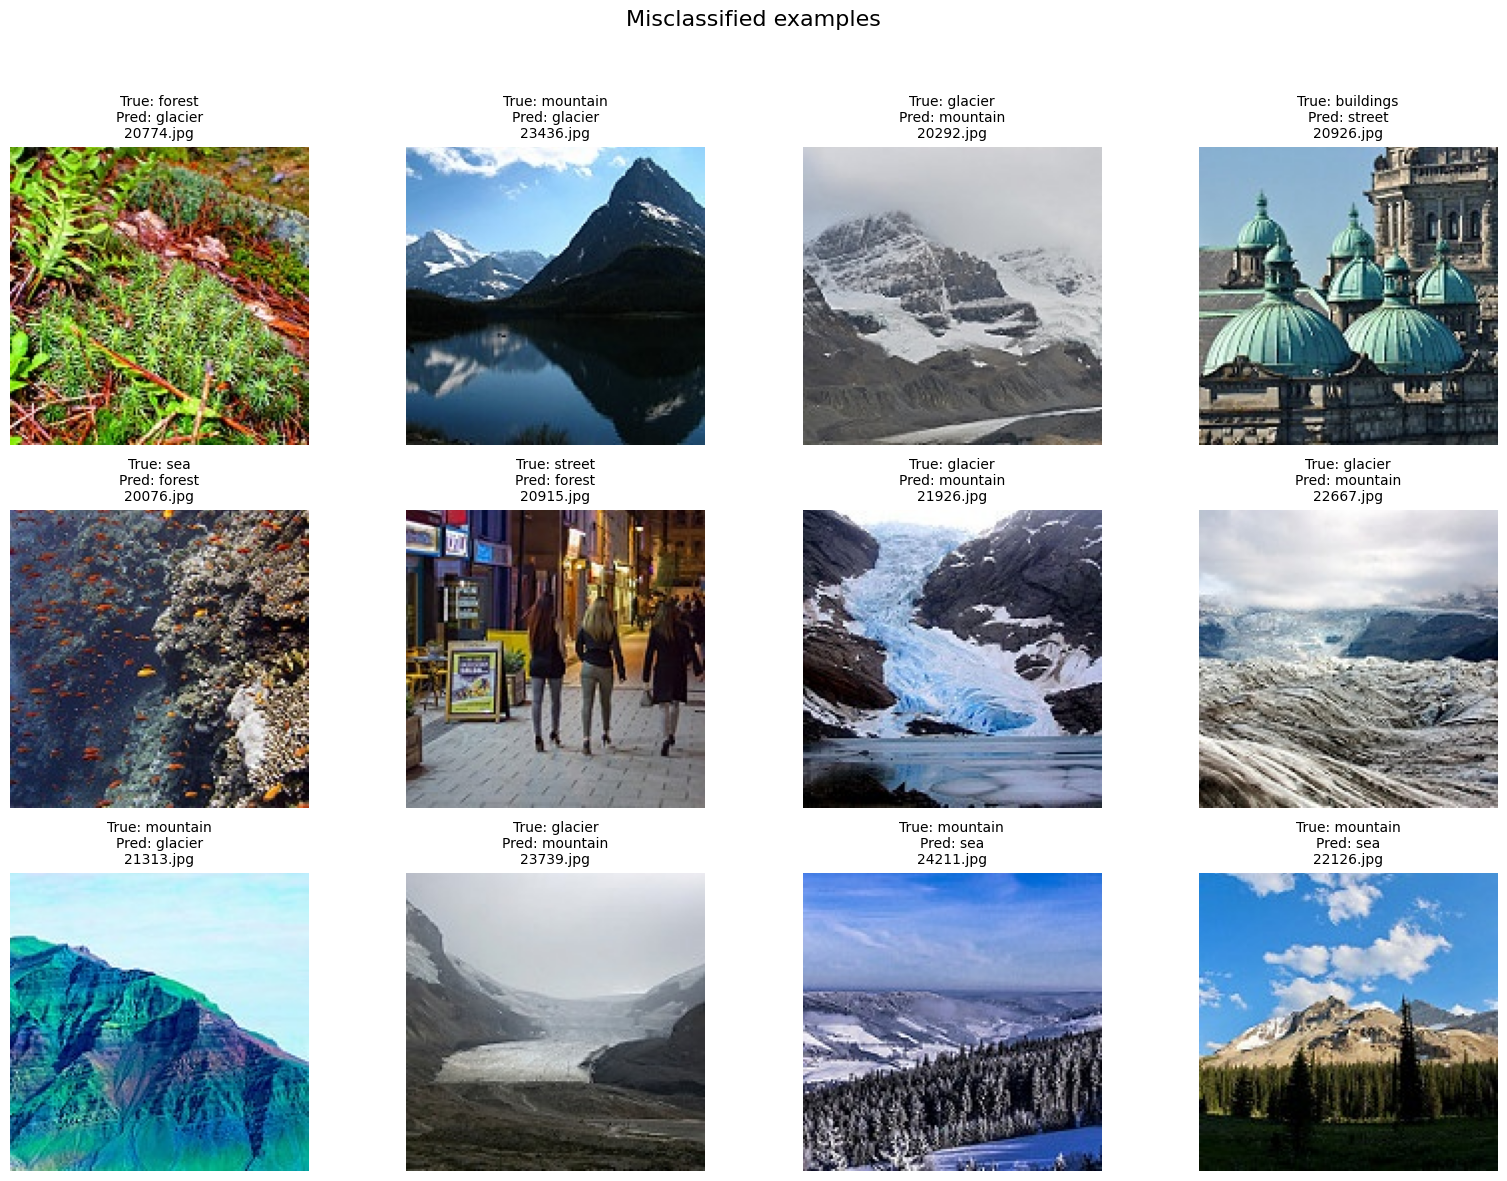

In [ ]:
def show_image_grid(rows_df, title, n=12, n_cols=4, save_path=None, random_sample=True):
    if "relative_path" not in rows_df.columns:
        print("Không có cột relative_path nên không thể hiển thị ảnh.")
        return

    if len(rows_df) == 0:
        print("Không có ảnh phù hợp để hiển thị.")
        return

    if random_sample:
        show_df = rows_df.sample(n=min(n, len(rows_df)), random_state=SEED).copy()
    else:
        show_df = rows_df.head(n).copy()

    n_images = len(show_df)
    n_rows = int(np.ceil(n_images / n_cols))

    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    plt.suptitle(title, fontsize=16)

    for plot_idx, (_, row) in enumerate(show_df.iterrows(), start=1):
        img_path = resolve_image_path(row["relative_path"])

        ax = plt.subplot(n_rows, n_cols, plot_idx)
        ax.axis("off")

        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, f"Không đọc được ảnh\n{img_path.name}\n{e}", ha="center", va="center")

        true_label = row.get("true_label", "?")
        pred_label = row.get("pred_label", "?")
        file_name = Path(str(row.get("relative_path", ""))).name

        ax.set_title(
            f"True: {true_label}\nPred: {pred_label}\n{file_name}",
            fontsize=10
        )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print("Đã lưu hình tại:", save_path)

    plt.show()


def show_misclassified_examples(true_label=None, pred_label=None, n=12, n_cols=4, save=True, random_sample=True):
    wrong_df = pred_df[pred_df["is_correct"] == False].copy()

    title_parts = ["Misclassified examples"]

    if true_label is not None:
        wrong_df = wrong_df[wrong_df["true_label"] == true_label]
        title_parts.append(f"True = {true_label}")

    if pred_label is not None:
        wrong_df = wrong_df[wrong_df["pred_label"] == pred_label]
        title_parts.append(f"Pred = {pred_label}")

    title = " | ".join(title_parts)

    save_path = None
    if save:
        safe_true = str(true_label) if true_label is not None else "all"
        safe_pred = str(pred_label) if pred_label is not None else "all"
        save_path = ERROR_EXAMPLES_DIR / f"misclassified_true_{safe_true}_pred_{safe_pred}_{MODE}.png"

    show_image_grid(
        rows_df=wrong_df,
        title=title,
        n=n,
        n_cols=n_cols,
        save_path=save_path,
        random_sample=random_sample
    )


show_misclassified_examples(n=12, n_cols=4, save=True, random_sample=True)


## 16. Hiển thị ảnh sai theo các cặp nhầm nhiều nhất

Cell này tự động lấy các cặp nhầm nhiều nhất từ bảng `top_confusions_nonzero_df` rồi hiển thị ảnh ví dụ.

Mặc định lấy 6 cặp nhầm nhiều nhất, mỗi cặp hiển thị tối đa 6 ảnh.


In [ ]:
TOP_K_CONFUSION_PAIRS = 6
N_EXAMPLES_PER_PAIR = 6

for _, row in top_confusions_nonzero_df.head(TOP_K_CONFUSION_PAIRS).iterrows():
    true_label = row["true_label"]
    pred_label = row["pred_label"]
    count = int(row["count"])
    rate = float(row["rate_within_true_class"])

    display(Markdown(
        f"### True `{true_label}` bị dự đoán nhầm thành `{pred_label}`\n"
        f"- Số lượng lỗi: **{count}**\n"
        f"- Tỉ lệ trong lớp thật `{true_label}`: **{rate:.2%}**"
    ))

    show_misclassified_examples(
        true_label=true_label,
        pred_label=pred_label,
        n=N_EXAMPLES_PER_PAIR,
        n_cols=3,
        save=True,
        random_sample=False
    )


Output hidden; open in https://colab.research.google.com to view.

## 17. Phân tích lỗi theo từng lớp thật

Cell này cho biết với mỗi lớp thật, khi model sai thì nó thường nhầm sang lớp nào.

Ví dụ: với lớp thật `glacier`, model có thể nhầm nhiều sang `mountain` hoặc `sea`.


In [ ]:
for class_name in class_names:
    class_wrong_df = pred_df[
        (pred_df["true_label"] == class_name) &
        (pred_df["is_correct"] == False)
    ].copy()

    total_class = int((pred_df["true_label"] == class_name).sum())
    wrong_class = len(class_wrong_df)

    display(Markdown(f"### Lớp thật: `{class_name}`"))
    print(f"Tổng số ảnh thật của lớp {class_name}: {total_class}")
    print(f"Số ảnh bị dự đoán sai: {wrong_class}")

    if wrong_class == 0:
        print("Không có lỗi cho lớp này.")
        continue

    error_dist = (
        class_wrong_df["pred_label"]
        .value_counts()
        .reset_index()
    )
    error_dist.columns = ["pred_label", "wrong_count"]
    error_dist["rate_within_true_class"] = error_dist["wrong_count"] / total_class
    error_dist["rate_among_errors"] = error_dist["wrong_count"] / wrong_class

    display(error_dist)


### Lớp thật: `buildings`

Tổng số ảnh thật của lớp buildings: 437
Số ảnh bị dự đoán sai: 129


,pred_label,wrong_count,rate_within_true_class,rate_among_errors
0,street,57,0.130435,0.441860
1,mountain,19,0.043478,0.147287
2,sea,19,0.043478,0.147287
3,glacier,18,0.041190,0.139535
4,forest,16,0.036613,0.124031


### Lớp thật: `forest`

Tổng số ảnh thật của lớp forest: 474
Số ảnh bị dự đoán sai: 50


...

Tổng số ảnh thật của lớp sea: 510
Số ảnh bị dự đoán sai: 229


,pred_label,wrong_count,rate_within_true_class,rate_among_errors
0,mountain,139,0.272549,0.606987
1,glacier,61,0.119608,0.266376
2,buildings,18,0.035294,0.078603
3,street,6,0.011765,0.026201
4,forest,5,0.009804,0.021834


### Lớp thật: `street`

Tổng số ảnh thật của lớp street: 501
Số ảnh bị dự đoán sai: 135


,pred_label,wrong_count,rate_within_true_class,rate_among_errors
0,buildings,58,0.115768,0.429630
1,forest,46,0.091816,0.340741
2,glacier,18,0.035928,0.133333
3,sea,7,0.013972,0.051852
4,mountain,6,0.011976,0.044444


## 18. So sánh nhanh baseline, tuning và test result

Cell này đọc lại các file metric có sẵn nếu tồn tại:

```text
outputs/metrics/cs114_baselines_metrics.csv
outputs/metrics/cs114_tuning_vs_baseline_full.csv
outputs/metrics/cs114_best_tuned_model_test_metrics_full.csv
```

Mục tiêu là tạo bảng ngắn để đưa vào báo cáo.


In [ ]:
baseline_metrics_path = METRICS_DIR / "cs114_baselines_metrics.csv"
tuning_vs_baseline_path = METRICS_DIR / f"cs114_tuning_vs_baseline_{MODE}.csv"
best_test_metrics_path = METRICS_DIR / f"cs114_best_tuned_model_test_metrics_{MODE}.csv"

comparison_rows = []

if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)
    for exp in ["hog_logistic_regression", "hog_linear_svm"]:
        row_df = baseline_df[baseline_df["experiment"] == exp]
        if len(row_df) > 0:
            row = row_df.iloc[0]
            comparison_rows.append({
                "stage": "baseline_validation",
                "experiment": exp,
                "accuracy": row.get("accuracy", np.nan),
                "macro_f1": row.get("macro_f1", np.nan),
                "source_file": baseline_metrics_path.name
            })

if tuning_vs_baseline_path.exists():
    tuning_cmp_df = pd.read_csv(tuning_vs_baseline_path)
    best_tuned_rows = tuning_cmp_df[tuning_cmp_df["stage"].astype(str).str.contains("tuned", case=False, na=False)]
    if len(best_tuned_rows) > 0:
        row = best_tuned_rows.iloc[-1]
        comparison_rows.append({
            "stage": "best_tuned_validation",
            "experiment": row.get("experiment", "best_tuned"),
            "accuracy": row.get("accuracy", np.nan),
            "macro_f1": row.get("macro_f1", np.nan),
            "source_file": tuning_vs_baseline_path.name
        })

if best_test_metrics_path.exists():
    test_df = pd.read_csv(best_test_metrics_path)
    if len(test_df) > 0:
        row = test_df.iloc[0]
        comparison_rows.append({
            "stage": "best_tuned_test",
            "experiment": row.get("experiment", "best_tuned"),
            "accuracy": row.get("accuracy", np.nan),
            "macro_f1": row.get("macro_f1", np.nan),
            "source_file": best_test_metrics_path.name
        })

comparison_summary_df = pd.DataFrame(comparison_rows)

if len(comparison_summary_df) > 0:
    comparison_summary_path = ERROR_TABLES_DIR / f"cs114_error_analysis_model_comparison_{MODE}.csv"
    comparison_summary_df.to_csv(comparison_summary_path, index=False)
    display(comparison_summary_df)
    print("Đã lưu bảng so sánh tại:", comparison_summary_path)
else:
    print("Không tìm thấy file metric để tạo bảng so sánh.")


,stage,experiment,accuracy,macro_f1,source_file
0,baseline_validation,hog_logistic_regression,0.583809,0.586621,cs114_baselines_metrics.csv
1,baseline_validation,hog_linear_svm,0.568474,0.570721,cs114_baselines_metrics.csv
2,best_tuned_validation,hog_logistic_regression,0.634451,0.638829,cs114_tuning_vs_baseline_full.csv
3,best_tuned_test,hog_logistic_regression,0.653000,0.659553,cs114_best_tuned_model_test_metrics_full.csv


Đã lưu bảng so sánh tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics/cs114_error_analysis_model_comparison_full.csv


## 19. Sinh đoạn nhận xét gợi ý cho báo cáo

Cell này tạo một đoạn nhận xét tự động dựa trên kết quả phân tích.

Bạn có thể copy đoạn này sang báo cáo rồi chỉnh lại văn phong nếu cần.


In [ ]:
best_classes = per_class_analysis_df.sort_values("f1-score", ascending=False).head(2)
worst_classes = per_class_analysis_df.sort_values("f1-score", ascending=True).head(3)
top_confusions_for_text = top_confusions_nonzero_df.head(5)

best_class_text = ", ".join([
    f"{row['class_name']} (F1={row['f1-score']:.4f})"
    for _, row in best_classes.iterrows()
])

worst_class_text = ", ".join([
    f"{row['class_name']} (F1={row['f1-score']:.4f})"
    for _, row in worst_classes.iterrows()
])

confusion_text = "; ".join([
    f"{row['true_label']} → {row['pred_label']} ({int(row['count'])} ảnh)"
    for _, row in top_confusions_for_text.iterrows()
])

report_paragraph = f'''
Kết quả phân tích lỗi trên test set cho thấy mô hình đạt accuracy = {accuracy:.4f}, với {n_correct}/{n_total} ảnh được dự đoán đúng. Các lớp có kết quả tốt nhất gồm {best_class_text}. Ngược lại, các lớp còn khó phân loại hơn gồm {worst_class_text}. Confusion matrix cho thấy những cặp lớp bị nhầm nhiều nhất là: {confusion_text}. Điều này cho thấy đặc trưng HOG kết hợp Logistic Regression có khả năng mô tả tốt cấu trúc cạnh và texture ở một số lớp như forest, street hoặc buildings, nhưng vẫn còn hạn chế với các lớp có đặc trưng thị giác gần nhau như mountain, glacier và sea. Đây là cơ sở để nhóm tiếp tục thử nghiệm các mô hình CNN hoặc transfer learning nhằm học được đặc trưng không gian và ngữ nghĩa cấp cao hơn từ ảnh gốc.
'''.strip()

display(Markdown("### Đoạn nhận xét gợi ý"))
print(report_paragraph)

report_text_path = ERROR_TABLES_DIR / f"cs114_error_analysis_report_paragraph_{MODE}.txt"
with open(report_text_path, "w", encoding="utf-8") as f:
    f.write(report_paragraph)

print("\nĐã lưu đoạn nhận xét tại:")
print(report_text_path)


### Đoạn nhận xét gợi ý

Kết quả phân tích lỗi trên test set cho thấy mô hình đạt accuracy = 0.6530, với 1959/3000 ảnh được dự đoán đúng. Các lớp có kết quả tốt nhất gồm forest (F1=0.8592), street (F1=0.7485). Ngược lại, các lớp còn khó phân loại hơn gồm mountain (F1=0.5005), glacier (F1=0.5542), sea (F1=0.5711). Confusion matrix cho thấy những cặp lớp bị nhầm nhiều nhất là: sea → mountain (139 ảnh); glacier → mountain (135 ảnh); mountain → glacier (128 ảnh); mountain → sea (93 ảnh); glacier → sea (72 ảnh). Điều này cho thấy đặc trưng HOG kết hợp Logistic Regression có khả năng mô tả tốt cấu trúc cạnh và texture ở một số lớp như forest, street hoặc buildings, nhưng vẫn còn hạn chế với các lớp có đặc trưng thị giác gần nhau như mountain, glacier và sea. Đây là cơ sở để nhóm tiếp tục thử nghiệm các mô hình CNN hoặc transfer learning nhằm học được đặc trưng không gian và ngữ nghĩa cấp cao hơn từ ảnh gốc.

Đã lưu đoạn nhận xét tại:
/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_pro

## 20. Tổng kết output của notebook

Sau khi chạy xong notebook này, các file quan trọng được tạo ra gồm:

### Metrics / Tables

```text
outputs/metrics/cs114_error_analysis_overall_full.json
outputs/metrics/cs114_error_analysis_per_class_full.csv
outputs/metrics/cs114_error_analysis_top_confusions_full.csv
outputs/metrics/cs114_error_analysis_confusion_matrix_raw_full.csv
outputs/metrics/cs114_error_analysis_confusion_matrix_normalized_full.csv
outputs/metrics/cs114_error_analysis_model_comparison_full.csv
outputs/metrics/cs114_error_analysis_report_paragraph_full.txt
```

### Figures

```text
outputs/figures/cs114/error_analysis/per_class_f1_best_tuned_model_full.png
outputs/figures/cs114/error_analysis/per_class_accuracy_best_tuned_model_full.png
outputs/figures/cs114/error_analysis/confusion_matrix_raw_best_tuned_model_full.png
outputs/figures/cs114/error_analysis/confusion_matrix_normalized_best_tuned_model_full.png
outputs/figures/cs114/error_analysis/misclassified_examples/*.png
```
